In [1]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import ROOT


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [26]:

path_npz = Path("/home/leoperes/sag_analysis/coincidence/")

ch_2070_run_039510 = np.load(path_npz / "channel_2070_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2071_run_039510 = np.load(path_npz / "channel_2071_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2080_run_039510 = np.load(path_npz / "channel_2080_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2081_run_039510 = np.load(path_npz / "channel_2081_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2070_run_039511 = np.load(path_npz / "channel_2070_run_039511_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2071_run_039511 = np.load(path_npz / "channel_2071_run_039511_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2080_run_039511 = np.load(path_npz / "channel_2080_run_039511_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2081_run_039511 = np.load(path_npz / "channel_2081_run_039511_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2070_run_039512 = np.load(path_npz / "channel_2070_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2071_run_039512 = np.load(path_npz / "channel_2071_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2080_run_039512 = np.load(path_npz / "channel_2080_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")
ch_2081_run_039512 = np.load(path_npz / "channel_2081_run_039512_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_10_ticks_min_amplitude_1000_adc.npz")


list_waveforms_mean = [ch_2070_run_039510,
ch_2071_run_039510,
ch_2080_run_039510,
ch_2081_run_039510,
ch_2070_run_039511,
ch_2071_run_039511,
ch_2080_run_039511,
ch_2081_run_039511,
ch_2070_run_039512,
ch_2071_run_039512,
ch_2080_run_039512,
ch_2081_run_039512]

In [27]:
path_templates = Path("/home/leoperes/sag_analysis/filter/templates_large_pulses/")
templates_ch_2070 = np.loadtxt(path_templates / "template_43229_M7_1.txt")
templates_ch_2071 = np.loadtxt(path_templates / "template_43229_M7_2.txt")
templates_ch_2080 = np.loadtxt(path_templates / "template_42321_M8_1.txt")
templates_ch_2081 = np.loadtxt(path_templates / "template_42321_M8_2.txt")

list_templates = [templates_ch_2070, templates_ch_2071, templates_ch_2080, templates_ch_2081]

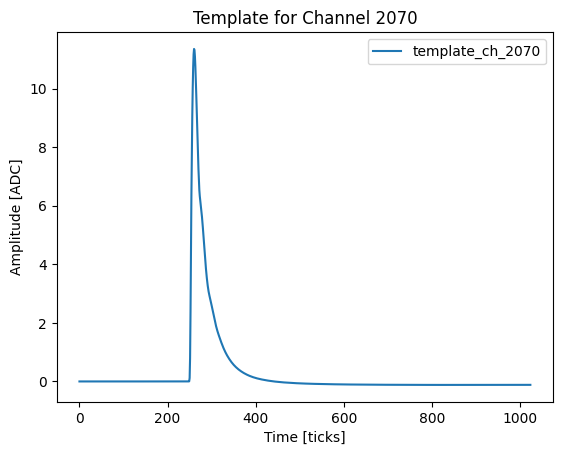

In [28]:
plt.figure()
plt.plot(templates_ch_2070, label="template_ch_2070")
plt.xlabel("Time [ticks]")
plt.ylabel("Amplitude [ADC]")
plt.title("Template for Channel 2070")
plt.legend()
plt.show()

In [29]:
def Calc_Charge(waveform, template):
    return np.trapz(waveform[50:500])/np.trapz(template)


In [38]:
list_ly=[]
for idx, waveform_mean in enumerate(list_waveforms_mean):
    charge = Calc_Charge(waveform_mean["mean"], list_templates[idx % 4])
    print(f"Charge for waveform {idx}: {charge}")
    list_ly.append(charge)
list_ly= np.asarray(list_ly)

Charge for waveform 0: 339.7806190815328
Charge for waveform 1: 361.11213396547595
Charge for waveform 2: 703.995791949033
Charge for waveform 3: 687.539363164938
Charge for waveform 4: 322.984011056704
Charge for waveform 5: 346.472833907094
Charge for waveform 6: 666.468701493361
Charge for waveform 7: 653.660770416243
Charge for waveform 8: 316.44000947872735
Charge for waveform 9: 337.104151662384
Charge for waveform 10: 639.3133830330614
Charge for waveform 11: 628.6636086195389


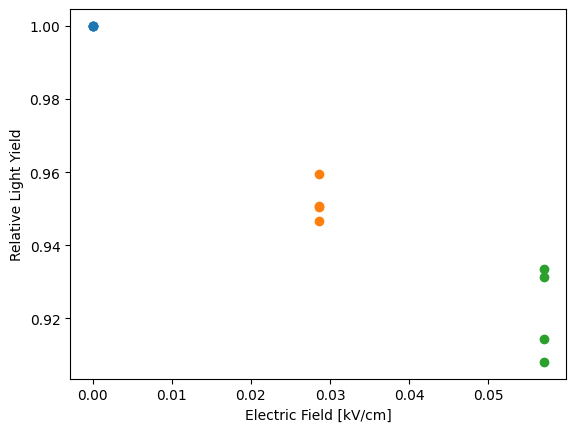

In [55]:
plt.figure(dpi=100)
plt.scatter([0.0,0.0,0.0,0.0],list_ly[0:4]/list_ly[0:4], label="0kV", marker='o')
plt.scatter([0.0286,0.0286,0.0286,0.0286],list_ly[4:8]/list_ly[0:4], label="10kV", marker='o')
plt.scatter([0.057,0.057,0.057,0.057],list_ly[8:12]/list_ly[0:4], label="20kV", marker='o')
plt.xlabel("Electric Field [kV/cm]")
plt.ylabel("Relative Light Yield")      
plt.show()